In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
PREDSDIR  = CONFIGS['filepaths']['predictions']
SPLIT     = 'valid'

# Predictors to show: listed in display order (2 rows x 3 cols)
PREDICTORS = [
    ('rh',         True,  'RH (%)'),
    ('thetae',     True,  '$\\mathit{\\theta_{e}}$ (K)'),
    ('thetaestar', True,  '$\\mathit{\\theta_{e}}^*$ (K)'),
    ('lf',         False, 'LF'),
    ('shf',        False, 'SHF (W/m$^2$)'),
    ('lhf',        False, 'LHF (W/m$^2$)'),
]  # (varname, has_sig_dim, xlabel)

_MODELS  = CONFIGS['experiments']
MODELS_8 = ['pod_bl',
            # 'nn_bl',
            # 'nn_full',
            # 'nn_nonparam',
            # 'nn_gauss',
            'sr_lo','sr_med','sr_hi']
LABELS_8 = {}
for _name,_rc in _MODELS['pod']['runs'].items():
    LABELS_8[_name] = _rc.get('description',_name)
# for _name,_rc in _MODELS['nn']['runs'].items():
#     LABELS_8[_name] = _rc.get('description',_name)
for _name,_eqspec in _MODELS['sr'].get('optimizedeqs',{}).items():
    LABELS_8[_name] = _eqspec.get('description',_name)
# Color + linestyle per model (colors match pareto.ipynb)
STYLES = {
    'pod_bl':        ('#921519',  '-',  1.2),
    # 'nn_bl':         ('#fa862d',  '-',  1.2),
    # 'nn_full':       ('#1b2c63',  '-',  1.2),
    # 'nn_nonparam':   ('#245ba7',  '-',  1.2),
    # 'nn_gauss':      ('#5ca7db',  '-',  1.2),
    'sr_lo':         ('#c41d24',  '-',  1.2),
    'sr_med':        ('#fce998',  '-',  1.2),
    'sr_hi':         ('#a3ddf7',  '-',  1.2),
}
NBINS = 50

In [4]:
# Load stats for denormalization
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    stats = json.load(f)

# Load normalized split for predictor values
with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    normds = {v:ds[v].load() for v in ds.data_vars}

# Build normalized (z-scored) and native-unit predictor arrays.
# Field variables: simple vertical mean over sigma levels (not kernel-integrated).
ref_dims = ('time','lat','lon')
refshape = tuple(normds['tp'].sizes[d] for d in ref_dims)
refsize  = int(np.prod(refshape))

norm_flat   = {}  # z-scored values for SR formula evaluation
native_flat = {}  # native units for x-axis bin centers
for varname,has_sig,_ in PREDICTORS:
    if varname not in normds:
        print(f'Warning: {varname} not in norm split, skipping')
        continue
    da = normds[varname]
    if has_sig and 'sig' in da.dims:
        da = da.mean('sig')
    da    = da.transpose(*[d for d in ref_dims if d in da.dims])
    vmean = stats.get(f'{varname}_mean', 0.0)
    vstd  = stats.get(f'{varname}_std',  1.0)
    arr   = da.values.ravel()
    if arr.size == refsize:
        norm_flat[varname]   = arr
        native_flat[varname] = arr * vstd + vmean
    else:
        full = np.broadcast_to(da.values[...,np.newaxis] if 'lon' not in da.dims else da.values, refshape)
        norm_flat[varname]   = full.ravel()
        native_flat[varname] = full.ravel() * vstd + vmean

# Load observations and BL (native units, non-normalized split)
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()
    bl_da  = ds.bl.load()
true_flat = truetp.transpose(*ref_dims).values.ravel()
bl_flat   = bl_da.transpose(*ref_dims).values.ravel()

# Load pod_bl model parameters
_pod_npz  = np.load(os.path.join(CONFIGS['filepaths']['models'],'pod','pod_bl.npz'))
pod_alpha = float(_pod_npz['alpha'])
pod_xcrit = float(_pod_npz['xcrit'])

# tp normalization stats (for SR formula output denormalization)
tp_mean = float(stats['tp_mean'])
tp_std  = float(stats['tp_std'])


# SR functions namespace (mirrors optimize.py)
SRFUNCTIONS = {
    'cube':lambda x:x**3, 'square':lambda x:x**2, 'neg':lambda x:-x,
    'sqrt':np.sqrt, 'exp':np.exp, 'log':np.log, 'abs':np.abs,
}

# Load optimized SR constants from registry pkl (written by scripts/models/sr/optimize.py)
_registrypath = os.path.join(CONFIGS['filepaths']['models'],'sr','optimized_equations.pkl')
if os.path.exists(_registrypath):
    with open(_registrypath,'rb') as _f:
        SR_REGISTRY = pickle.load(_f)
else:
    print(f'Warning: optimized_equations.pkl not found — SR models will be skipped')
    SR_REGISTRY = {}

valid_mask = np.isfinite(true_flat)
print(f'Valid samples: {valid_mask.sum():,}  |  pod_bl: alpha={pod_alpha:.4f}, xcrit={pod_xcrit:.4f}')
print(f'SR models in registry: {list(SR_REGISTRY.keys())}')

Valid samples: 1,437,408  |  pod_bl: alpha=523.0024, xcrit=-0.0083
SR models in registry: ['sr_bl', 'sr_lo', 'sr_med', 'sr_hi']


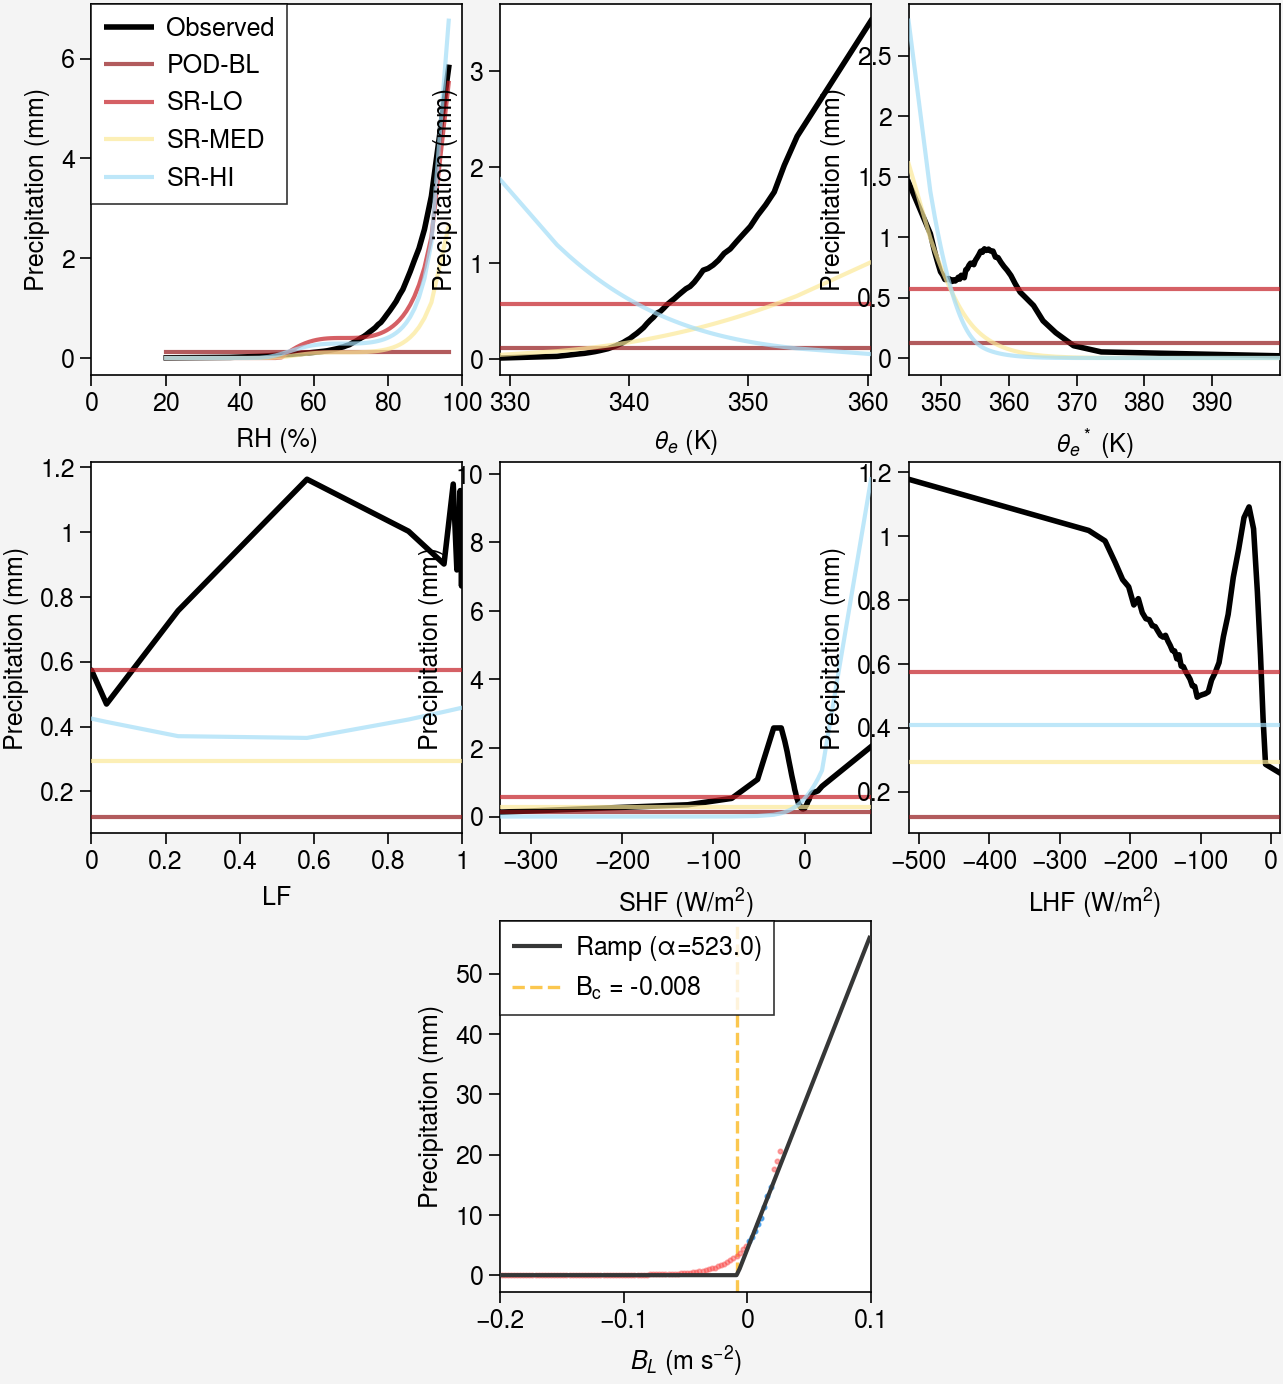

In [5]:
def bin_conditional(x_flat, y_flat, nbins=50):
    '''Bin y by quantiles of x; return (bin_edges, bin_centers, bin_means).'''
    finite  = np.isfinite(x_flat) & np.isfinite(y_flat)
    x,y     = x_flat[finite], y_flat[finite]
    edges   = np.quantile(x, np.linspace(0, 1, nbins+1))
    centers = 0.5 * (edges[:-1] + edges[1:])
    means   = np.full(nbins, np.nan)
    for i in range(nbins):
        sel = (x >= edges[i]) & (x <= edges[i+1])
        if sel.sum() >= 5:
            means[i] = y[sel].mean()
    return edges, centers, means

def _form_vars(name):
    '''Return the set of predictor names (keys of norm_flat) used in this model\'s formula.'''
    if name not in SR_REGISTRY:
        return set()
    form = SR_REGISTRY[name]['form']
    all_names = {n.id for n in ast.walk(ast.parse(form, mode='eval'))
                 if isinstance(n, ast.Name)}
    return all_names & set(norm_flat.keys())

def _eval_sr(name, norm_vals):
    entry = SR_REGISTRY[name]
    ns    = dict(SRFUNCTIONS, __builtins__={})
    ns.update(entry['constants'])
    ns.update(norm_vals)
    out = eval(entry['form'], ns)
    if np.ndim(out) == 0:
        n   = next((len(v) for v in norm_vals.values() if hasattr(v,'__len__')), 1)
        out = np.full(n, float(out))
    return np.asarray(out, dtype=float)

def _denorm_tp(y_norm):
    return np.maximum(0.0, np.expm1(y_norm * tp_std + tp_mean))

def partial_dependence_curve(model_name, varname, bin_edges):
    '''
    Compute the Friedman partial dependence of model_name w.r.t. varname.

    For each bin center v (native units), v is converted to a z-score and
    substituted for varname across every sample while all other predictors
    retain their observed values.  The model formula is evaluated and
    predictions are averaged over the full dataset.

    Predictors not in the model formula produce a flat line at the model's
    unconditional mean prediction.  pod_bl, which uses only BL, is flat
    on all panels here since BL is not one of the shown predictors.
    '''
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    vmean   = stats.get(f'{varname}_mean', 0.0)
    vstd    = stats.get(f'{varname}_std',  1.0)

    if model_name == 'pod_bl':
        pod_preds = pod_alpha * np.maximum(0.0, bl_flat - pod_xcrit)
        return centers, np.full(len(centers), np.nanmean(pod_preds))

    if model_name not in SR_REGISTRY:
        return centers, np.full(len(centers), np.nan)

    uses      = _form_vars(model_name)
    base_norm = {vn: norm_flat[vn] for vn in uses if vn in norm_flat}

    if varname not in uses:
        y_norm    = _eval_sr(model_name, base_norm)
        mean_pred = np.nanmean(_denorm_tp(y_norm))
        return centers, np.full(len(centers), mean_pred)

    pd_vals = np.full(len(centers), np.nan)
    for i, v_native in enumerate(centers):
        v_norm         = (v_native - vmean) / vstd
        sweep          = dict(base_norm)
        sweep[varname] = v_norm
        y_norm         = _eval_sr(model_name, sweep)
        pd_vals[i]     = np.nanmean(_denorm_tp(y_norm))
    return centers, pd_vals

# ── Layout: 3×3 grid; panels 1–6 are PD plots, panel 7 is the POD ramp fit ──
array   = [[1,2,3],[4,5,6],[0,7,0]]
fig,axs = pplt.subplots(array,figwidth=6.5,sharex=False,sharey=False,
                        tight=True,hspace=3.5,wspace=1.5)
axs = np.atleast_1d(axs).ravel()
pd_axs   = axs[:6]   # panels 1–6
ramp_ax  = axs[6]    # panel 7

# ── Partial-dependence panels ─────────────────────────────────────────────────
avail_preds = [(vn,hs,xl) for vn,hs,xl in PREDICTORS if vn in native_flat]
for pd_ax in pd_axs:
    pd_ax.format(grid=False, gridminor=False, ylabel='Precipitation (mm)')

for col,(varname,_,xlabel) in enumerate(avail_preds):
    ax   = pd_axs[col]
    xarr = native_flat[varname]

    edges,centers,obs_means = bin_conditional(xarr, true_flat, NBINS)
    ax.plot(centers, obs_means, color='k', lw=2, ls='-', label='Observed', zorder=0)

    for name in MODELS_8:
        color,ls,lw = STYLES[name]
        _,pd_means  = partial_dependence_curve(name, varname, edges)
        ax.plot(centers, pd_means, color=color, ls=ls, lw=1.5, alpha=0.7,
                label=LABELS_8.get(name,name), zorder=5)

    ax.format(xlabel=xlabel, xminorticks='none', yminorticks='none')

pd_axs[0].format(xlim=(0,100), xticks=20)
pd_axs[1].format(xticks=10)
pd_axs[2].format(xticks=10)
pd_axs[3].format(xlim=(0,1),  xticks=0.2)
pd_axs[4].format(xticks=100)
pd_axs[5].format(xticks=100)
pd_axs[0].legend(loc='ul', ncols=1)

# ── POD ramp-fit panel ────────────────────────────────────────────────────────
_pod_npz  = np.load(os.path.join(CONFIGS['filepaths']['models'],'pod','pod_bl.npz'))
xbins     = _pod_npz['bincenters']
ymeans    = _pod_npz['ymean']
fitrange  = _pod_npz['fitrange'].astype(bool)

ramp_ax.scatter(xbins[~fitrange], ymeans[~fitrange],
                color='red6', marker='.', s=10, alpha=0.5, zorder=2)
ramp_ax.scatter(xbins[fitrange],  ymeans[fitrange],
                color='blue6', marker='.', s=10, alpha=0.7, zorder=3)
ramp_ax.plot(xbins, pod_alpha*np.maximum(0.0, xbins-pod_xcrit),
             color='dark gray', lw=1.5, zorder=4,
             label=f'Ramp ($\\alpha$={pod_alpha:.1f})')
ramp_ax.axvline(pod_xcrit, color='yellow6', alpha=0.7, ls='--', lw=1.2, zorder=1,
                label=f'$B_c$ = {pod_xcrit:.3f}')
ramp_ax.format(xlabel='$\\mathit{B_L}$ (m s$^{-2}$)',
               ylabel='Precipitation (mm)',
               xlim=(-0.2, 0.1),
               grid=False, gridminor=False,
               xminorticks='none', yminorticks='none')
ramp_ax.legend(loc='ul', ncols=1)

pplt.show()
fig.save('../figs/fig_2.jpg')